In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
folder = "/content/drive/MyDrive/Clean_Shop_Videos"

video_names = np.load(os.path.join(folder,"video_names.npy"), allow_pickle=True)
labels = np.load(os.path.join(folder,"clean_labels.npy"), allow_pickle=True)

video_paths = [os.path.join(folder, name) for name in video_names]

print("videos:", len(video_paths))
print("labels:", len(labels))

videos: 637
labels: 637


In [ ]:
from sklearn.model_selection import train_test_split

train_videos, val_videos, train_labels, val_labels = train_test_split(
    video_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

train_videos, test_videos, train_labels, test_labels = train_test_split(
    train_videos,
    train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=42
)

print("Train:", len(train_videos))
print("Validation:", len(val_videos))
print("Test:", len(test_videos))

Train: 432
Validation: 128
Test: 77


In [ ]:
# 5. Parameters

IMG_SIZE = 224
NUM_FRAMES = 32
BATCH_SIZE = 16
EPOCHS = 10
feature_dir = "/content/drive/MyDrive/features_shop"
os.makedirs(feature_dir, exist_ok=True)

In [ ]:
#  Data Augmentation

datagen = ImageDataGenerator(
    rotation_range=3,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

In [ ]:
def augment_frames(frames):
    augmented = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented.append(frame)
    return np.array(augmented)

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 8. Extract Frames

def extract_frames(video_path, num_frames=NUM_FRAMES):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        return np.zeros((num_frames, IMG_SIZE, IMG_SIZE, 3))

    frame_indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    frames = []
    current_frame = 0
    frame_set = set(frame_indices)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if current_frame in frame_set:
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        current_frame += 1
    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])

    return np.array(frames)


In [ ]:
# 9. Extract & Save Features
def extract_and_save_features(video_paths, prefix, augment=False):
    feature_paths = []
    for i, path in enumerate(tqdm(video_paths)):
        save_path = os.path.join(feature_dir, f"{prefix}_{i}.npy")
        if os.path.exists(save_path):
            feature_paths.append(save_path)
            continue

        frames = extract_frames(path)
        if augment:
            frames = augment_frames(frames)

        frames = preprocess_input(frames)
        features = base_model(frames, training=False)
        features = tf.reduce_mean(features, axis=0).numpy()
        np.save(save_path, features)
        feature_paths.append(save_path)
    return feature_paths

In [ ]:
# 10. Feature Generator

class FeatureGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=BATCH_SIZE):
        self.paths = paths
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(paths))

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X = np.array([np.load(self.paths[i]) for i in batch_idx])
        y = np.array([self.labels[i] for i in batch_idx])
        return X, y

In [ ]:
# 10. Build Model

model = models.Sequential([
    layers.Input(shape=(2048,)),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# 12. Run Feature Extraction

train_feature_paths = extract_and_save_features(train_videos, "train", augment=True)


100%|██████████| 432/432 [12:58<00:00,  1.80s/it]


In [ ]:
val_feature_paths = extract_and_save_features(val_videos, "val", augment=False)


100%|██████████| 128/128 [02:35<00:00,  1.22s/it]


In [ ]:
test_feature_paths = extract_and_save_features(test_videos, "test", augment=False)

100%|██████████| 77/77 [01:42<00:00,  1.34s/it]


In [ ]:
train_gen = FeatureGenerator(train_feature_paths, train_labels, batch_size=BATCH_SIZE)
val_gen = FeatureGenerator(val_feature_paths, val_labels, batch_size=BATCH_SIZE)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.8264 - loss: 0.5625 - val_accuracy: 0.5859 - val_loss: 0.5811
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9074 - loss: 0.1927 - val_accuracy: 0.7656 - val_loss: 0.5150
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9421 - loss: 0.1624 - val_accuracy: 0.7344 - val_loss: 0.5197
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9606 - loss: 0.1174 - val_accuracy: 0.7812 - val_loss: 0.4980
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9468 - loss: 0.1231 - val_accuracy: 0.7422 - val_loss: 0.4631
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9583 - loss: 0.1374 - val_accuracy: 0.8047 - val_loss: 0.3540
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9699 - loss: 0.0680 - val_accuracy: 0.8203 - val_loss: 0.4203
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9676 - loss: 0.0951 - val_accuracy: 0.8203 - val_loss: 0

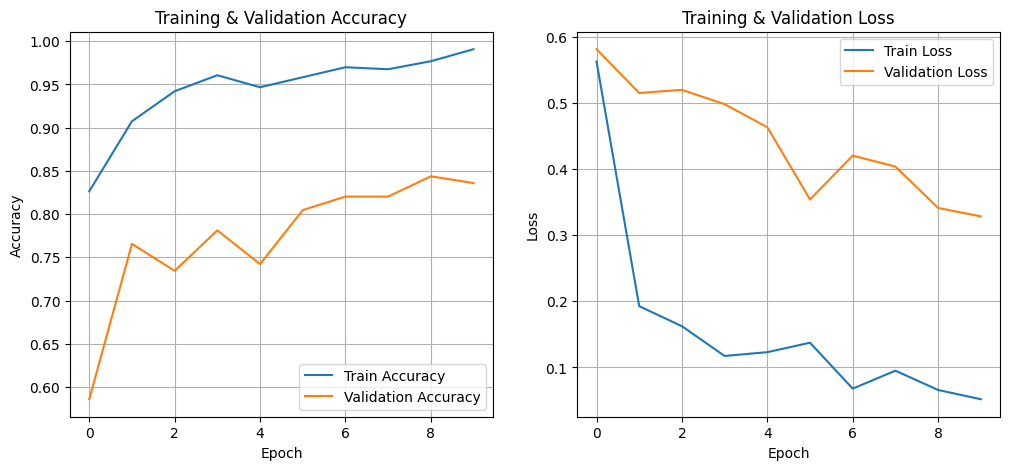

In [ ]:

# 15. Plot Accuracy & Loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# 14. Evaluate on Test Data

test_gen = FeatureGenerator(test_feature_paths, test_labels, batch_size=BATCH_SIZE)
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


              precision    recall  f1-score   support

           0     0.8333    0.7895    0.8108        38
           1     0.8049    0.8462    0.8250        39

    accuracy                         0.8182        77
   macro avg     0.8191    0.8178    0.8179        77
weighted avg     0.8189    0.8182    0.8180        77



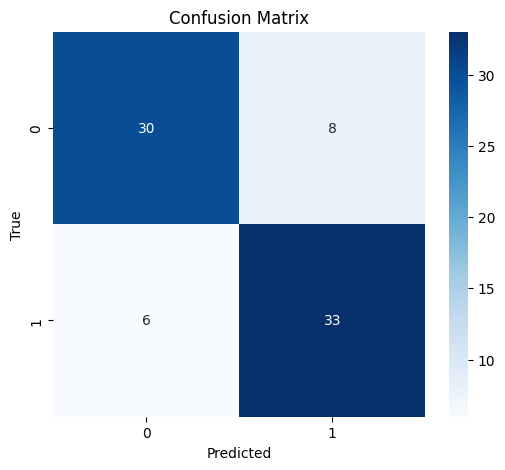

In [ ]:
# Classification Report
print(classification_report(test_labels, y_pred, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()